In [1]:
import numpy as np
import pandas as pd
from sklearn.linear_model import LinearRegression

In [4]:
X = np.array([[1, 1], [1, 2], [2, 2], [2, 3]])
# y = 1 * x_0 + 2 * x_1 + 3
y = np.dot(X, np.array([1, 2])) + 3
reg = LinearRegression().fit(X, y)
reg.score(X, y)
reg.coef_
reg.intercept_
reg.predict(np.array([[3, 5]]))

array([16.])

In [5]:
reg.coef_

array([1., 2.])

In [3]:
df = pd.read_csv("Combined_table.csv")
df

,Rk,Pos,90s,Tkl,TklW,Def 3rd,Mid 3rd,Att 3rd,Tkl.1,Att,...,Off,Crs,Int.1,TklW.1,PKcon,OG,Recov,Won,Lost.1,Won%
0,1,DF,13.7,29,19,20,7,2,20,34,...,2,13,8,19,1,0,75,5,11,31.3
1,3,MF,1.1,2,2,1,1,0,1,1,...,0,0,0,2,0,0,5,3,0,100.0
2,5,DF,30.9,64,35,36,23,5,26,45,...,0,3,39,35,0,1,149,61,37,62.2
3,6,MF,16.9,21,14,8,10,3,8,18,...,0,3,12,14,3,0,89,2,7,22.2
4,7,DF,2.0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,10,4,6,40.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1601,2845,DF,28.0,32,25,20,10,2,19,26,...,0,3,32,25,1,0,156,83,81,50.6
1602,2846,MF,29.5,49,27,18,29,2,23,42,...,0,7,37,27,0,0,169,44,28,61.1
1603,2847,MF,9.6,15,6,5,8,2,5,15,...,2,6,6,6,0,0,37,7,17,29.2
1604,2849,MF,34.3,49,17,18,21,10,17,58,...,3,77,15,17,0,0,158,3,9,25.0


In [21]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Encode the target variable (Pos)
label_encoder = LabelEncoder()
df['Pos'] = label_encoder.fit_transform(df['Pos'])

# Define features (X) and target variable (y)
X = df.drop(columns=['Pos'])  # Drop target column
X = df.drop(columns=['Pos.1', '90s', '90s.1'])  # Drop target column
y = df['Pos']  # Target variable

# Handle missing values (fill with mean for simplicity)
X.fillna(X.mean(), inplace=True)

# Normalize features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Split data
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

# Train a classifier
clf = RandomForestClassifier(random_state=42)
clf.fit(X_train, y_train)

# Predict and evaluate
y_pred = clf.predict(X_test)
accuracy = accuracy_score(y_test, y_pred)

print(f'Classification Accuracy: {accuracy:.2f}')


Classification Accuracy: 0.97


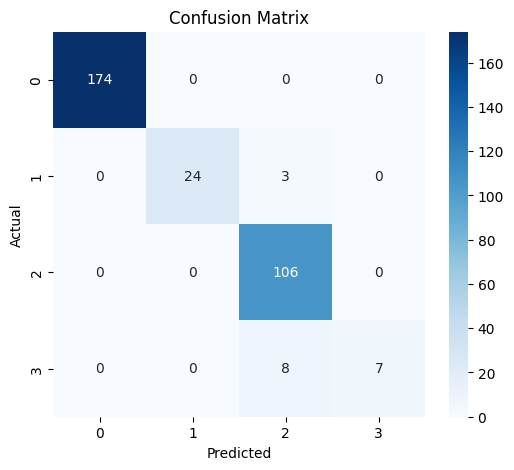

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix, classification_report

# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Plot confusion matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=label_encoder.classes_, yticklabels=label_encoder.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


In [23]:
X.iloc[:, 10:30]

,Lost,Blocks,Sh,Pass,Int,Tkl+Int,Clr,Err,Rk.1,CrdY,CrdR,2CrdY,Fls,Off,Crs,Int.1,TklW.1,PKcon,OG,Recov
0,14,9,5,4,8,37,27,0,1,1,0,0,12,2,13,8,19,1,0,75
1,0,2,0,2,0,2,0,0,3,0,0,0,6,0,0,0,2,0,0,5
2,19,51,32,19,39,103,109,2,5,5,0,0,26,0,3,39,35,0,1,149
3,10,12,1,11,12,33,18,0,6,2,0,0,34,0,3,12,14,3,0,89
4,1,0,0,0,0,0,4,0,7,0,0,0,1,0,0,0,0,0,0,10
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1601,7,28,19,9,32,64,97,3,2845,11,1,0,43,0,3,32,25,1,0,156
1602,19,33,9,24,37,86,54,0,2846,5,0,0,36,0,7,37,27,0,0,169
1603,10,5,1,4,6,21,11,0,2847,4,0,0,19,2,6,6,6,0,0,37
1604,41,23,1,22,15,64,5,0,2849,2,0,0,30,3,77,15,17,0,0,158


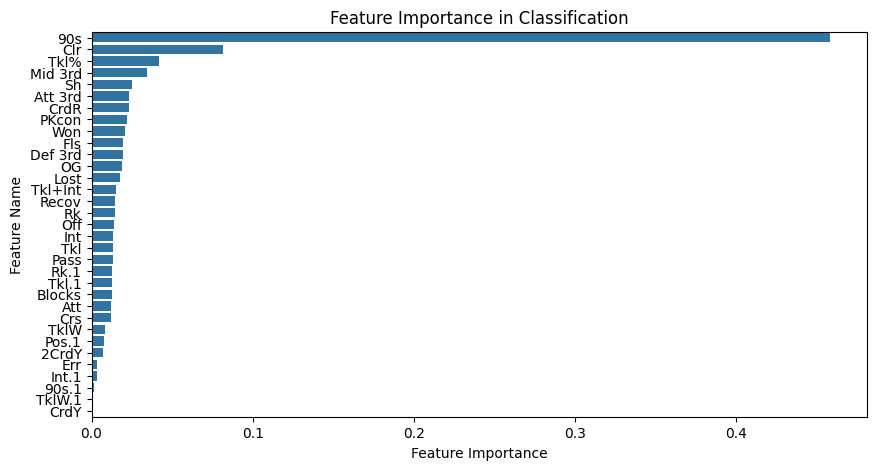

In [24]:
import numpy as np

# Get feature importance
feature_importances = clf.feature_importances_
feature_names = df.drop(columns=['Pos']).columns  # Get feature names
# Sort by importance
sorted_indices = np.argsort(feature_importances)[::-1]

# Plot feature importance
plt.figure(figsize=(10, 5))
sns.barplot(x=feature_importances[sorted_indices], y=[feature_names[i] for i in sorted_indices])
plt.xlabel("Feature Importance")
plt.ylabel("Feature Name")
plt.title("Feature Importance in Classification")
plt.show()
